## Random tiebreaking for tree packings

This notebook accompanies the paper "Matroid Base Packings: Improved Dynamic Matroid Density and Combinatorics of Tree Packings". We test whether randomized tree packings can yield relative load errors proportional to $1/\sqrt{k}$. We use graphs $G_n$ described in the paper. In these graphs, every edge has ideal relative load
$$
\ell_e^*=\frac{n-1}{2n-1}.
$$

We compute the values $\|L^k-k\ell^*\|_\infty$. Growth proportional to $\sqrt{k}$ corresponds to the error in relative loads proportional to $1/\sqrt{k}$.

We run the experiments for $G_{100}, G_{300}, G_{1000}, G_{3000}$ using four different seeds for randomization. For each number of vertices $n \in \{100, 300, 1000, 3000\}$, we pack $n^2 / 100$ trees. The factor $1/100$ is an experimental choice. At the end of the notebook, we include a longer run for $G_{100}$ for comparison.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [2]:
n_values = (100, 300, 1000, 3000)
c = 100
seeds = (42, 67, 1729, 47_176_870)
display_seed = 67
illustration_n = 300
profile_n = max(n_values)
num_trees = {n: n * n // c for n in n_values}

experiment_dir = Path.cwd()
if not (experiment_dir / 'tree-packings.ipynb').exists():
    raise FileNotFoundError()
results_dir = experiment_dir / 'results'
results_dir.mkdir(exist_ok=True)

### The graph construction

The vertices are $1,\ldots,n$. There is a path on vertices $2,\ldots,n$, vertex $1$ is adjacent to all other vertices, and edges $(1,2)$ and $(1,n)$ are doubled.

In [3]:
def fan_multigraph(n):
    """Return the multigraph G_n from the paper."""
    if n < 3:
        raise ValueError("n must be at least 3")

    graph = nx.MultiGraph()
    graph.add_nodes_from(range(1, n + 1))

    graph.add_edge(1, 2)
    graph.add_edge(1, 2)
    for vertex in range(3, n + 1):
        graph.add_edge(vertex - 1, vertex)
        graph.add_edge(1, vertex)
    graph.add_edge(1, n)

    return graph

A small example of the construction:

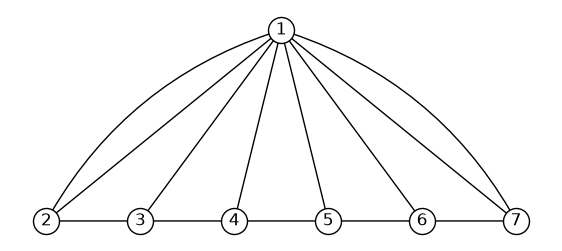

In [4]:
example_n = 7
example = fan_multigraph(example_n)
pos = {
    1: ((example_n - 2) / 2, 2),
    **{v: (v - 2, 0) for v in range(2, example_n + 1)},
}
fig, ax = plt.subplots(figsize=(example_n, 3))
nx.draw_networkx_nodes(
    example, pos, node_color='white', edgecolors='black',
    node_size=350, ax=ax,
)
nx.draw_networkx_labels(example, pos, ax=ax)
for u, v, key in example.edges:
    radius = 0
    if v == 2 and key == 0:
        radius = 0.2
    elif v == example_n and key == 1:
        radius = -0.2
    nx.draw_networkx_edges(
        example, pos, edgelist=[(u, v, key)],
        connectionstyle=f'arc3,rad={radius}', ax=ax,
    )
ax.set_axis_off()

### Randomized greedy packing and saved results

At every iteration, we find a minimum spanning tree with respect to the edge weights being the integral edge loads perturbed by fresh independent noise from $[0,0.1]$. Then equal-load edges appear in a uniformly random order, but the order of edges with different loads is unchanged.

For every simulation, we store the error at each step and the final load vector. We save the data into
files in `results/`. Later we can load existing data.

In the largest run, we pack 90,000 trees per seed in a graph with 3,000 vertices; this may take a couple of hours to compute with NetworkX.

In [5]:
def simulate_packing(n, num_trees, seed):
    """Return the error trajectory, final loads, and their edge order."""
    graph = fan_multigraph(n)
    edges = list(graph.edges)
    assert len(edges) == 2 * n - 1
    edge_index = {edge: i for i, edge in enumerate(edges)}
    loads = np.zeros(len(edges), dtype=np.int64)
    errors = np.empty(num_trees)
    ideal_load = (n - 1) / (2 * n - 1)
    rng = np.random.default_rng(seed)

    for k in range(1, num_trees + 1):
        weights = loads + rng.uniform(0, 0.1, len(edges))
        nx.set_edge_attributes(graph, dict(zip(edges, weights)), 'weight')
        tree = nx.minimum_spanning_tree(graph, weight='weight')
        for edge in tree.edges:
            loads[edge_index[edge]] += 1
        errors[k - 1] = np.max(np.abs(loads - k * ideal_load))

    return dict(errors=errors, final_loads=loads, edges=np.asarray(edges))


cache_version = 1

def run_or_load(n, num_trees, seed):
    """Cache one completed run; never reuse a different parameter setting."""
    path = results_dir / f'fan-v{cache_version}-n{n}-k{num_trees}-seed{seed}.npz'
    if path.exists():
        with np.load(path, allow_pickle=False) as saved:
            result = {key: saved[key].copy() for key in saved.files}
        assert int(result['n']) == n
        assert int(result['num_trees']) == num_trees
        assert int(result['seed']) == seed
        assert int(result['cache_version']) == cache_version
        assert result['errors'].shape == (num_trees,)
        assert result['final_loads'].shape == (2 * n - 1,)
        assert result['edges'].shape == (2 * n - 1, 3)
        print(f'Loaded {path.name}', flush=True)
        return result

    print(f'Running n={n}, trees={num_trees}, seed={seed}', flush=True)
    result = simulate_packing(n, num_trees, seed)
    result.update(n=n, num_trees=num_trees, seed=seed,
                  cache_version=cache_version,
                  numpy_version=np.__version__, networkx_version=nx.__version__)
    temporary_path = path.with_suffix('.tmp.npz')
    np.savez_compressed(temporary_path, **result)
    temporary_path.replace(path)
    return result

Run the experiments or load existing data:

In [6]:
results = {
    (n, seed): run_or_load(n, num_trees[n], seed)
    for n in n_values
    for seed in seeds
}

Loaded fan-v1-n100-k100-seed42.npz
Loaded fan-v1-n100-k100-seed67.npz
Loaded fan-v1-n100-k100-seed1729.npz
Loaded fan-v1-n100-k100-seed47176870.npz
Loaded fan-v1-n300-k900-seed42.npz
Loaded fan-v1-n300-k900-seed67.npz
Loaded fan-v1-n300-k900-seed1729.npz
Loaded fan-v1-n300-k900-seed47176870.npz
Loaded fan-v1-n1000-k10000-seed42.npz
Loaded fan-v1-n1000-k10000-seed67.npz
Loaded fan-v1-n1000-k10000-seed1729.npz
Loaded fan-v1-n1000-k10000-seed47176870.npz
Loaded fan-v1-n3000-k90000-seed42.npz
Loaded fan-v1-n3000-k90000-seed67.npz
Loaded fan-v1-n3000-k90000-seed1729.npz
Loaded fan-v1-n3000-k90000-seed47176870.npz


### Error behavior

We show a plot of $\|L^k-k\ell^*\|_\infty$ versus $k$ for each graph size, with four trajectories corresponding to the four seeds. The dashed curve is a fixed $\sim \sqrt{k}$ reference.

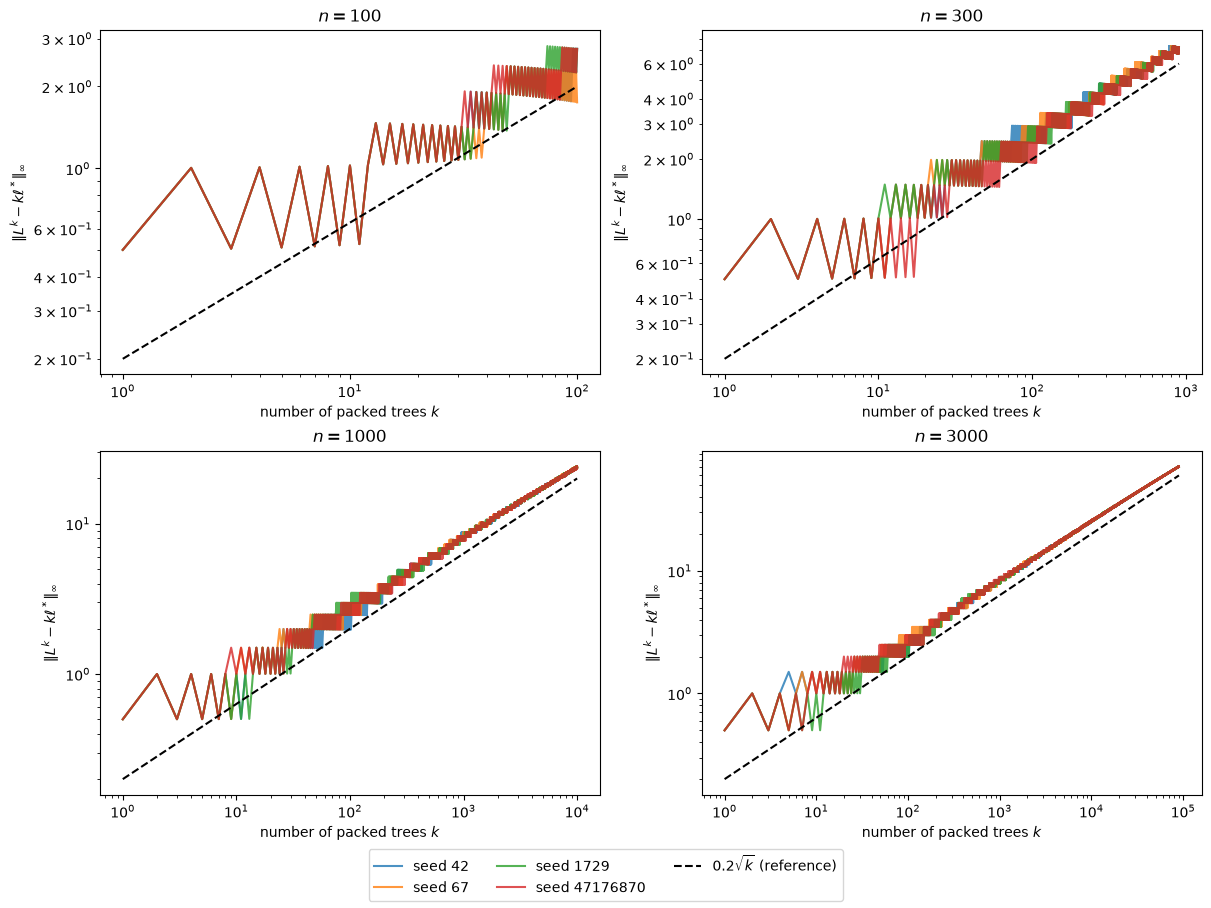

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, n in zip(axes.flat, n_values):
    k = np.arange(1, num_trees[n] + 1)
    for seed in seeds:
        ax.plot(k, results[n, seed]['errors'], alpha=0.8, label=f'seed {seed}')
    ax.plot(k, 0.2 * np.sqrt(k), 'k--', label=r'$0.2\sqrt{k}$ (reference)')
    ax.set(xscale='log', yscale='log', xlabel='number of packed trees $k$',
           ylabel=r'$\|L^k-k\ell^*\|_\infty$', title=f'$n={n}$')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3);

### How final edge loads look like

Below, we visualize the final state of loads. We observe that there are two regions of underpacked edges at the ends of the graph.

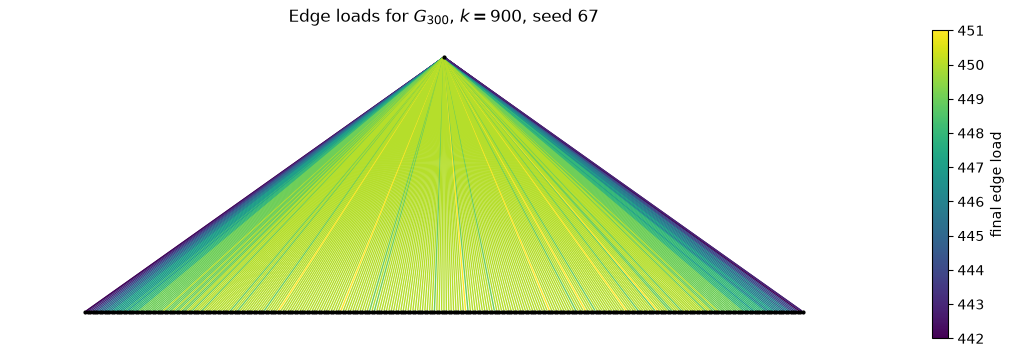

In [8]:
n = illustration_n
graph = fan_multigraph(n)
pos = {
    1: ((n - 2) / 2, n / 5),
    **{v: (v - 2, 0) for v in range(2, n + 1)},
}
final_loads = results[n, display_seed]['final_loads']
normalization = plt.Normalize(final_loads.min(), final_loads.max())

fig, ax = plt.subplots(figsize=(14, 4))
nx.draw_networkx_nodes(
    graph, pos, node_color='black', node_size=4, ax=ax,
)
nx.draw_networkx_edges(
    graph, pos, edgelist=list(graph.edges),
    edge_color=final_loads, edge_cmap=plt.cm.viridis,
    edge_vmin=final_loads.min(), edge_vmax=final_loads.max(),
    width=1., node_size=4, ax=ax,
)
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=normalization, cmap=plt.cm.viridis,
    ),
    ax=ax, label='final edge load',
)
ax.set_title(
    f'Edge loads for $G_{{{n}}}$, $k={num_trees[n]}$, '
    f'seed {display_seed}',
)
ax.set_axis_off()

Text(0.5, 1.0, 'Final loads for $G_{3000}$, $k=90000$, seed 67')

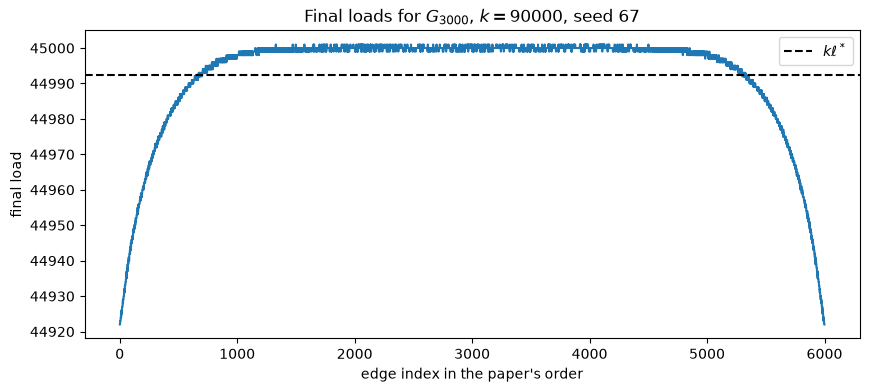

In [9]:
n = profile_n
final_loads = results[n, display_seed]['final_loads']
paper_edge_order = [(1, 2, 0), (1, 2, 1)]
for vertex in range(3, n + 1):
    paper_edge_order.extend([
        (vertex - 1, vertex, 0), (1, vertex, 0),
    ])
paper_edge_order.append((1, n, 1))

edge_index = {
    edge: index for index, edge in enumerate(map(tuple, results[n, display_seed]['edges']))
}
ordered_loads = [
    final_loads[edge_index[edge]] for edge in paper_edge_order
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    np.arange(1, len(paper_edge_order) + 1), ordered_loads,
)
ax.axhline(num_trees[n] * (n - 1) / (2 * n - 1), color='black',
           linestyle='--', label=r'$k \ell^*$')
ax.legend()
ax.set_xlabel("edge index in the paper's order")
ax.set_ylabel('final load')
ax.set_title(
    f'Final loads for $G_{{{n}}}$, $k={num_trees[n]}$, '
    f'seed {display_seed}',
)

### Longer run for $n=100$ and finite-size effects 

Finally, we show what happens if we pack very many trees. For $G_{100}$, we consider a packing of $n^2=10000$ trees. The vertical line shows the cutoff $k/n^2=1/100$ that we used in the main experiment above. The errors start curving down. My intuition is that the underpacked regions at the ends of the graph do not fit inside the graph anymore; therefore the error in the integer loads plattoes if we pack very many trees.

Loaded fan-v1-n100-k10000-seed42.npz
Loaded fan-v1-n100-k10000-seed67.npz
Loaded fan-v1-n100-k10000-seed1729.npz
Loaded fan-v1-n100-k10000-seed47176870.npz


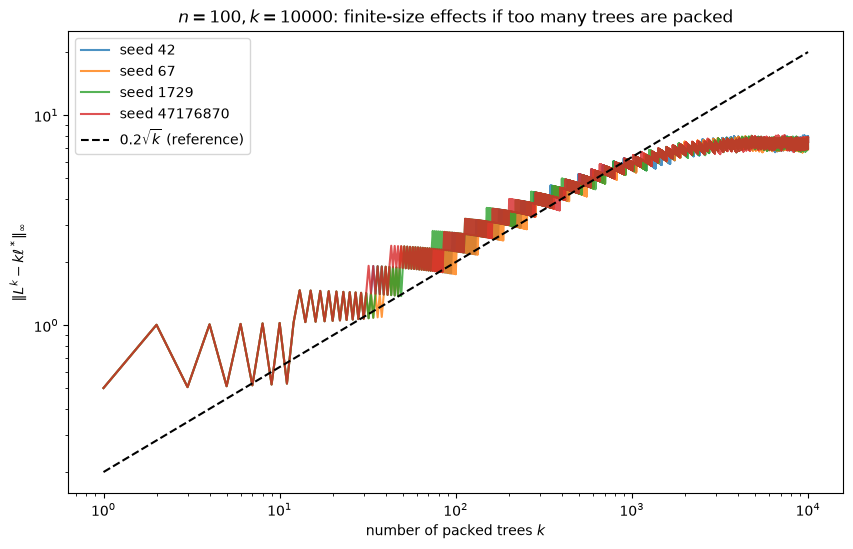

In [10]:
long_n = 100
long_num_trees = long_n**2
long_results = {seed: run_or_load(long_n, long_num_trees, seed) for seed in seeds}
    
k = np.arange(1, long_num_trees + 1)
fig, ax = plt.subplots(figsize=(10, 6))
for seed in seeds:
    ax.plot(k, long_results[seed]['errors'], alpha=0.8, label=f'seed {seed}')
ax.plot(k, 0.2 * np.sqrt(k), 'k--', label=r'$0.2\sqrt{k}$ (reference)')
ax.set(xscale='log', yscale='log', xlabel='number of packed trees $k$',
        ylabel=r'$\|L^k-k\ell^*\|_\infty$', title=f'$n={long_n}, k={long_num_trees}$: finite-size effects if too many trees are packed')
ax.legend();

### Conclusion

Across several random seeds and several graph sizes, the values $\lVert L^k-k\ell^*\rVert_\infty$ seem to grow proportional to $\sqrt{k}$ in the range $k \leq n^2/100$. Thus, the relative-load error is of order $1/\sqrt{k}$. This is experimental evidence that random tie-breaking on the edges might not help for the $\ell_\infty$-error in tree packings. However, this is just empirical evidence and not a proof. Also, it does not rule out the possibility that with a different kind of randomization, one could obtain a more optimistic bound on the error.